# Inspect a saved CPPN

This notebook studies a fixed network exported by either human or automated selection. It does not breed networks or load a classifier. Save your selection in notebook 01 first, then open this notebook in the project kernel.

The first question is **what does this network compute?** The second is **what changes when we intervene on that computation?** An attractive activation map is a hypothesis about a mechanism, not proof of semantic factorisation or reuse.

Inspired by activation maps and weight sweeps in [Kumar et al., section 3 and Appendix D](https://arxiv.org/html/2505.11581v1). Our node clamps and connection removals are additional exploratory tests.


In [34]:
from pathlib import Path
from IPython.display import display
from PIL import Image

from automated_picbreeder.interpretability import load_network, replay_experiment, trace_network
from automated_picbreeder.interpretability_notebook import CPPNInspector

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


## 1. Choose the saved network

Set `SESSION_PATH` to a run directory or its `session.json`. `GENOME_ID = None` loads the selection recorded at export, which is not necessarily the newest genome. Set a numeric ID to inspect another candidate. If the session has no selection, an explicit ID is required.

In [43]:
# Example: SESSION_PATH = ROOT / "runs" / "your-saved-human-session"
SESSION_PATH = '../runs/offspring-value-imagenet-200x10-prev-gird-ref/run-0001-seed8/session.json'
GENOME_ID = None

if SESSION_PATH is None:
    print("Set SESSION_PATH above, then rerun this cell and the following cells.")
    print("Saved sessions:")
    for path in sorted((ROOT / "runs").glob("**/session.json")):
        print(path.relative_to(ROOT))


Verified genome #1594 at 96 × 96 pixels.


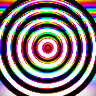

In [44]:
network = None
if SESSION_PATH is not None:
    network = load_network(SESSION_PATH, genome_id=GENOME_ID)
    print(f"Verified genome #{network.genome.key} at {network.size} × {network.size} pixels.")
    display(Image.fromarray(trace_network(network).rgb))


## 2. Inspect and intervene

The graph shows the evaluated computation, with unused genes retained and labelled. Each thumbnail is a node's activation over `(x, y, radius)`. The y coordinate increases downwards. The same network is evaluated separately at every pixel; the radius input already supplies a symmetric feature.

1. Select a connection weight. The interface names its source and destination and shows the original/current weight. Below the final images, compare the unchanged source activation with the destination’s original and modified activations. The destination is highlighted in the graph.
2. Move the slider to apply an **absolute value** when you release it. Every change starts from the saved original. The weight scales the source activation before it enters the destination neuron; map colours show numerical activation, not final image colour. Selecting a node bias instead shows that node’s original and modified activations.
3. Try **Disable connection** or **Clamp activation**, then press **Apply intervention**. A clamp replaces the post-activation value at every pixel; it is not a bias edit. Zero is one possible clamp value, not a universally neutral baseline.
4. **Reset to original** removes the intervention. For a clamp, the displayed starting value is the baseline spatial mean; no clamp is applied until requested.
5. Set the sweep limits and sample count, then run a sweep. Each sample is independent. The sweep limits can extend beyond the slider's local ±1 interval.

Maps use blue for negative, white for zero, red for positive. Each node keeps its baseline scale during interventions, so larger values can saturate the display; numerical ranges remain visible. Compare spatial patterns across nodes cautiously because their scales differ.

Hue, saturation and brightness output maps in the graph show raw values before the renderer's hue wrap, saturation clip, and absolute-value/clip of brightness. A raw activation change can be hidden by those transforms. The RGB difference view uses absolute byte differences on a fixed 0–255 scale, with no amplification.


In [47]:
inspector = None
save_dir = '/'.join(SESSION_PATH.split('/')[:-1]) + '/interpretability'
if network is not None:
    inspector = CPPNInspector(network, save_dir=save_dir)
    display(inspector)

## 3. Save an observation

Use the Observation field and **Save experiment** button. It saves the current intervention and any displayed sweep, together with a baseline genome, embedded configuration, resolution, source identity, package versions and result PNGs in a new directory. It never updates the source session.

A useful note names the proposed role, the exact observed changes, what remained stable and any counterexample. For example: "Changing this connection alters both circular regions; the outer contour appears stable over these values." That observation alone does not establish a shared eye mechanism: global brightness could also change both regions. Trace the relevant intermediate computation and test alternatives.

These are exploratory observations, not a validated UFR score. The original human and automated networks can be examined with the same tools, but a comparison also needs a defined network sample and intervention protocol.


In [ ]:
# Paste a directory reported by Save experiment to verify the recording.
EXPERIMENT_PATH = None
if EXPERIMENT_PATH is not None:
    baseline, results = replay_experiment(EXPERIMENT_PATH)
    print(f"Verified baseline and {len(results)} saved interventions.")


Restart the kernel after changing imported project modules, then rerun the cells. Existing inspector instances retain the code with which they were created.
